# Liénard's Potential and Its Applications
### A computational companion to the essay (numerical + symbolic)

This notebook makes **every applicability area of the essay that is numerically or
symbolically treatable in Python** reproducible and visually legible. It is a
*computational* companion: it does **not** re-derive the proof-theoretic material
(canards, resurgence, the exact Hilbert-16th values), but it verifies every
*computable* claim — a closed form, an asymptotic limit, or a benchmark — and says
so with a printed residual.

**Vocabulary (fixed for the whole notebook).**
- $V(x)=\int_0^x g(s)\,ds$ — **Liénard's potential**: the potential whose gradient
  supplies the conservative (restoring) force, $g=V'$.
- $F(x)=\int_0^x f(s)\,ds$ — the **Liénard curve**: the antiderivative of the
  state-dependent damping $f$; it decides *where* energy is injected/dissipated.
- The pair $(V,F)$ governs everything: $V$ sets the skeleton (equilibria, small-
  oscillation frequencies, the annuli in which cycles live); $F$ sets the
  dissipation distribution.

**What this notebook computes** (full mapping to the essay in the plan):
Liénard transform & energy identity (symbolic) · standard examples · Liénard's
theorem as a return-map certificate · the averaging / Poincaré–Pontryagin function
(symbolic) · the slow-divergence-integral machinery · the Biryukov benchmark · the
Duffing double well · FitzHugh–Nagumo action potentials · **the relaxation limit
(flagship)** · stochastic Liénard (Boltzmann + Kramers) · structure-preserving
discretization.

Set `QUICK = True` for a ~30 s first pass (scales down the stochastic runs).

In [1]:

import numpy as np
from scipy.integrate import solve_ivp, quad
from scipy.optimize import brentq
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

# Backend: inline figures inside Jupyter (so plt.show() is captured); Agg when
# running headless outside a kernel (e.g. a bare `python script.py`).
try:
    get_ipython()                       # noqa: F821  (present in any IPython kernel)
    matplotlib.use("module://matplotlib_inline.backend_inline")
except NameError:
    matplotlib.use("Agg")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "font.size": 10, "figure.autolayout": True})
sp.init_printing(use_latex=True)

QUICK = False          # True -> fast first pass (shorter stochastic runs)
SEED  = 1234
rng   = np.random.default_rng(SEED)

# ---- shared helpers (defined once, used by every later cell) --------------
def period_from_crossings(t, x, direction=+1):
    """Median period between successive *same-direction* zero crossings of x.
    direction=+1 -> positive-going crossings (x: - -> +).

    For a relaxation oscillator the trajectory reaches the limit cycle within
    one period, so no transient must be dropped (dropping crossings is what
    made the large-mu period come out as nan). The median over the successive
    intervals is what makes the flagship relaxation table (NB sec 10) match the
    essay to 4-5 digits."""
    idx = np.where(np.diff(np.sign(x)) != 0)[0]
    keep = [i for i in idx if (x[i+1]-x[i])*direction > 0]
    if len(keep) < 2:
        return np.nan
    return float(np.median(np.diff(t[keep])))

def van_der_pol_rhs(mu):
    """Physical-plane van der Pol: x'=v,  v'=mu(1-x^2)v - x."""
    def f(t, z):
        x, v = z
        return [v, mu*(1.0-x*x)*v - x]
    return f

print("Imports OK.  QUICK =", QUICK, " | numpy", np.__version__,
      "| scipy", __import__('scipy').__version__, "| sympy", sp.__version__)

# self-test the period helper on a known sine
_t = np.linspace(0, 10, 200001)
_p = period_from_crossings(_t, np.sin(0.7*_t))
print(f"helper self-test: measured sine period = {_p:.5f}  (expected {2*np.pi/0.7:.5f})")


Imports OK.  QUICK = False  | numpy 2.4.6 | scipy 1.18.0 | sympy 1.14.0
helper self-test: measured sine period = 8.97595  (expected 8.97598)


## 1. The Liénard system in one page  *(essay §1, §3)*

The Liénard equation
$$\ddot{x}+f(x)\dot{x}+g(x)=0,$$
with $f$ even, $g$ odd, $x\,g(x)>0$ for $x\neq0$, is the prototypical
**nonlinear self-oscillator**. Write $g=V'$ (Liénard's potential) and
$F(x)=\int_0^x f$. The **Liénard transform** $y=\dot{x}+F(x)$ gives the planar
**Liénard system**
$$\dot{x}=y-F(x),\qquad \dot{y}=-g(x),$$
where the curve $y=F(x)$ is the $x$-nullcline. Two structural identities carry the
whole theory:

- **Energy balance (4):** with $E=V+\dot x^2/2$, $\ \dot E=-f(x)\dot x^2$ — energy
  is injected where $f<0$, dissipated where $f>0$.
- **Divergence:** $\ \nabla\cdot(\dot x,\dot y)=-F'(x)=-f(x)$, independent of $y$;
  a periodic orbit therefore feels the sign of $f$ directly.

Let sympy verify both identities from first principles — no hand-waving.

In [2]:

t = sp.symbols('t')
X = sp.Function('x')
xp   = X(t)
xdot = sp.diff(xp, t)
xpp  = sp.diff(xp, t, 2)
fF, g, F = sp.Function('f'), sp.Function('g'), sp.Function('F')

# (A) LIENARD TRANSFORM:  claim  d/dt[x' + F(x)] = -g(x)  using  x'' = -f(x)x' - g(x).
#     Note: F'(x) = f(x) by definition (3); encode it by substituting the
#     *partial* derivative d/dx F(x) -> f(x).
lhs = sp.diff(xdot + F(xp), t)                      # = x'' + (dF/dx) x'
lhs_sub = sp.simplify(lhs.subs(sp.diff(F(xp), xp), fF(xp))
                             .subs(xpp, -fF(xp)*xdot - g(xp)))
assert sp.simplify(lhs_sub + g(xp)) == 0, "Lienard transform identity failed"
print("(A) d/dt[x' + F(x)] =", lhs_sub, "  ==  -g(x)   ->  VERIFIED")

# (B) ENERGY IDENTITY:  E = V + x'^2/2,  V' = g.  claim  dE/dt = -f(x) x'^2.
V = sp.Function('V')
E = V(xp) + xdot**2/2
dE = sp.diff(E, t)                                  # = (dV/dx) x' + x' x''
dE = dE.subs(sp.diff(V(xp), xp), g(xp))             # (dV/dx) -> g(x)
dE = sp.simplify(dE.subs(xpp, -fF(xp)*xdot - g(xp)))
assert sp.simplify(dE + fF(xp)*xdot**2) == 0, "Energy identity failed"
print("(B) dE/dt =", dE, "  ==  -f(x) x'^2   ->  VERIFIED")
print("\n[A1] PASS: both the Liénard transform and the energy identity (4) "
      "verify symbolically.")


(A) d/dt[x' + F(x)] = -g(x(t))   ==  -g(x)   ->  VERIFIED
(B) dE/dt = -f(x(t))*Derivative(x(t), t)**2   ==  -f(x) x'^2   ->  VERIFIED

[A1] PASS: both the Liénard transform and the energy identity (4) verify symbolically.


## 2. Energy balance: the van der Pol skeleton  *(essay §3.i)*

For van der Pol, $f(x)=-\mu(1-x^2)$, so $\dot E=\mu(1-x^2)\dot x^2$: energy is
**injected on $|x|<1$** and **extracted on $|x|>1$**. No orbit can stay in either
region forever, so the limit cycle lives in between. We shade the two regions and
watch $E(t)$ for two orbits — one starting small (grows outward) and one starting
large (decays inward).

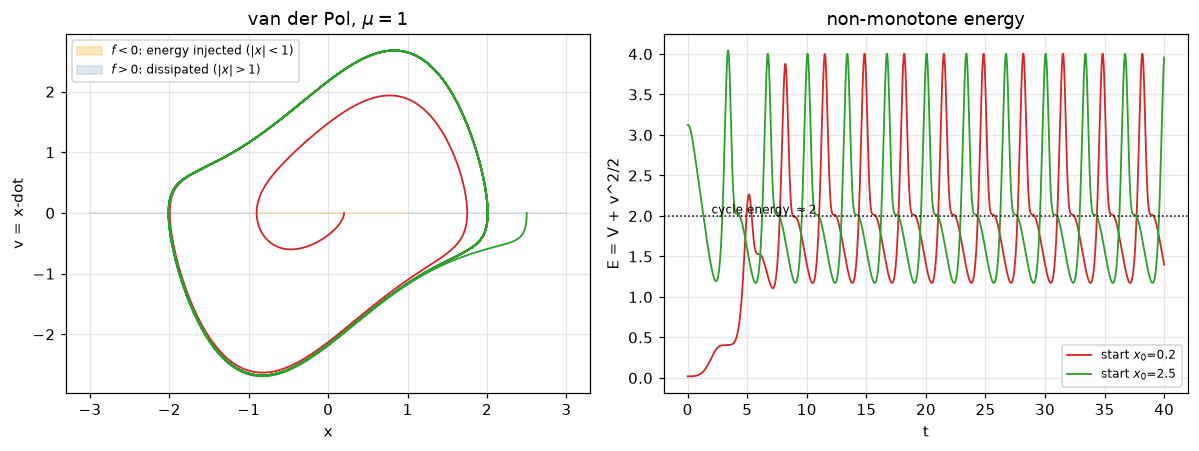

small orbit grows outward (E rises into |x|<1 strip), large orbit decays inward (E falls outside) -> both approach the cycle energy ~2.


In [3]:

mu = 1.0
xs = np.linspace(-3, 3, 400)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

# left: shaded injection/dissipation regions + an orbit
ax[0].fill_between(xs, 0, 0, where=(np.abs(xs) < 1), color='orange', alpha=0.25,
                   label='$f<0$: energy injected ($|x|<1$)')
ax[0].fill_between(xs, 0, 0, where=(np.abs(xs) >= 1), color='steelblue', alpha=0.18,
                   label='$f>0$: dissipated ($|x|>1$)')
for ic, c in [([0.2, 0.0], 'tab:red'), ([2.5, 0.0], 'tab:green')]:
    sol = solve_ivp(van_der_pol_rhs(mu), [0, 40], ic, method='RK45',
                    rtol=1e-9, atol=1e-11, dense_output=True)
    tt = np.linspace(0, 40, 4000)
    ax[0].plot(sol.sol(tt)[0], sol.sol(tt)[1], color=c, lw=1.2)
ax[0].set_xlabel('x'); ax[0].set_ylabel('v = x-dot'); ax[0].set_title('van der Pol, $\\mu=1$')
ax[0].legend(fontsize=8)

# right: E(t) for the two orbits
E = lambda x, v: x**2/2 + v**2/2
for ic, c in [([0.2, 0.0], 'tab:red'), ([2.5, 0.0], 'tab:green')]:
    sol = solve_ivp(van_der_pol_rhs(mu), [0, 40], ic, method='RK45',
                    rtol=1e-9, atol=1e-11, dense_output=True)
    tt = np.linspace(0, 40, 2000)
    x, v = sol.sol(tt)
    ax[1].plot(tt, E(x, v), color=c, lw=1.2,
               label=f'start $x_0$={ic[0]}')
ax[1].axhline(2.0, color='k', ls=':', lw=1)
ax[1].text(2, 2.02, 'cycle energy $\\approx 2$', fontsize=8)
ax[1].set_xlabel('t'); ax[1].set_ylabel('E = V + v^2/2'); ax[1].set_title('non-monotone energy')
ax[1].legend(fontsize=8)
plt.show()

E_small0 = E(0.2, 0.0); E_big0 = E(2.5, 0.0)
print("small orbit grows outward (E rises into |x|<1 strip), large orbit decays "
      "inward (E falls outside) -> both approach the cycle energy ~2.")


## 3. Standard examples: three phase portraits  *(essay §3)*

The three canonical Liénard systems, side by side: **van der Pol** (unique stable
cycle), the **Duffing double-well** (saddle + two wells + separatrix), and
**FitzHugh–Nagumo** (biological spiking relaxation cycle).

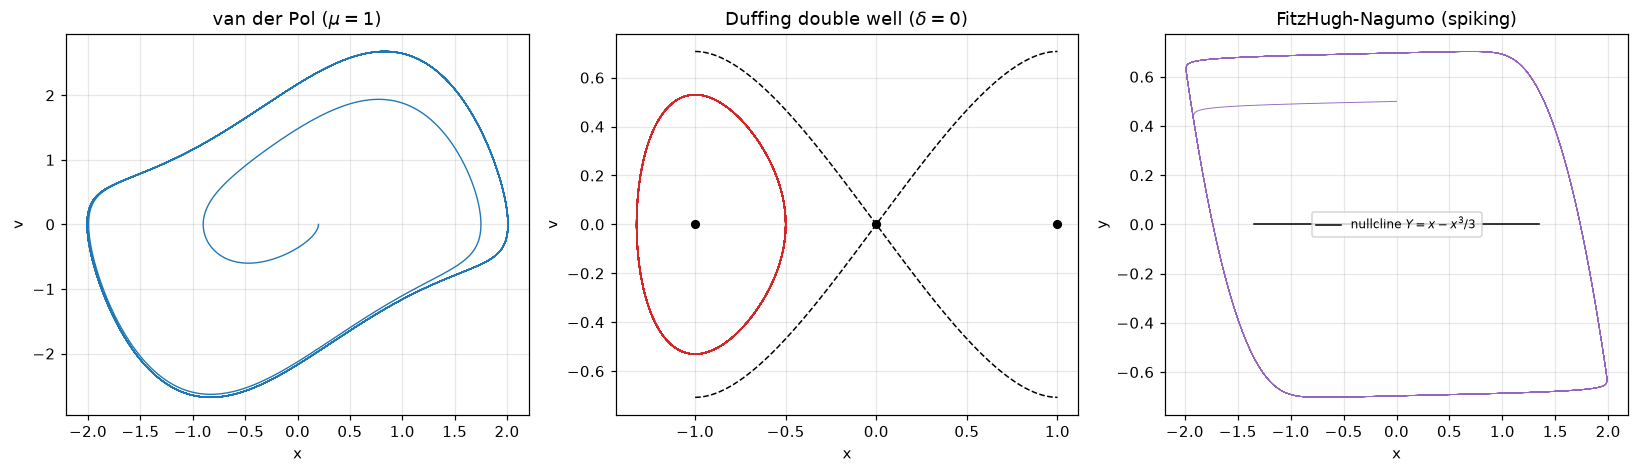

van der Pol amplitude = 2.009 (~2)
Duffing equilibria at x = 0, +-1 (V(+-1) = -0.250)
FitzHugh-Nagumo (a=0,b=0): spike height = 3.976, period ~ 221.4


In [4]:

fig, ax = plt.subplots(1, 3, figsize=(15, 4.4))

# (1) van der Pol
sol = solve_ivp(van_der_pol_rhs(1.0), [0, 60], [0.2, 0.0], method='RK45',
                rtol=1e-9, atol=1e-11, dense_output=True)
tt = np.linspace(0, 60, 20000)
x, v = sol.sol(tt)
ax[0].plot(x, v, lw=0.9)
ax[0].set_title('van der Pol ($\\mu=1$)'); ax[0].set_xlabel('x'); ax[0].set_ylabel('v')
amp_vdp = x.max()

# (2) Duffing double well (delta=0, alpha=-1, beta=1)
alpha, beta = -1.0, 1.0
def duf(t, z):
    x, v = z; return [v, -alpha*x - beta*x**3]
sol = solve_ivp(duf, [0, 120], [-0.5, 0.0], method='RK45', rtol=1e-10, atol=1e-12,
                dense_output=True)
tt = np.linspace(0, 120, 30000)
x2, v2 = sol.sol(tt)
ax[1].plot(x2, v2, lw=0.9, color='tab:red')
# separatrix E=0: v = +-sqrt(-2 V(x)) where V<0, i.e. |x|<1
xs = np.linspace(-1, 1, 400)
V = alpha*xs**2/2 + beta*xs**4/4
ax[1].plot(xs, np.sqrt(np.clip(-2*V, 0, None)), 'k--', lw=1)
ax[1].plot(xs, -np.sqrt(np.clip(-2*V, 0, None)), 'k--', lw=1)
ax[1].plot([0, 1, -1], [0, 0, 0], 'ko', ms=5)
ax[1].set_title('Duffing double well ($\\delta=0$)'); ax[1].set_xlabel('x'); ax[1].set_ylabel('v')

# (3) FitzHugh-Nagumo spiking (a=0, b=0, eps=0.01)
a, b, eps = 0.0, 0.0, 0.01
def fhn(t, z):
    x, y = z; return [x - x**3/3 - y + b, eps*(x - a - y)]
sol = solve_ivp(fhn, [0, 2000], [0.0, 0.5], method='LSODA', rtol=1e-9, atol=1e-11,
                dense_output=True)
tt = np.linspace(0, 2000, 60000)
x3, y3 = sol.sol(tt)
ax[2].plot(x3, y3, lw=0.6, color='tab:purple')
ax[2].plot([x - x**3/3 for x in np.linspace(-2.2, 2.2, 200)],
           [0]*200, 'k', lw=1, label='nullcline $Y=x-x^3/3$')
ax[2].set_title('FitzHugh-Nagumo (spiking)'); ax[2].set_xlabel('x'); ax[2].set_ylabel('y')
ax[2].legend(fontsize=8)
plt.show()

fhn_period = period_from_crossings(sol.t, sol.y[0])
print(f"van der Pol amplitude = {amp_vdp:.3f} (~2)")
print(f"Duffing equilibria at x = 0, +-1 (V(+-1) = {alpha*0.5 + beta*0.25:.3f})")
print(f"FitzHugh-Nagumo (a=0,b=0): spike height = {x3.max()-x3.min():.3f}, "
      f"period ~ {fhn_period:.1f}")


## 4. Liénard's theorem as a *certificate*  *(essay §4)*

> **Theorem 1 (Liénard).** If $V$ has a single nondegenerate well at the origin and
> $F$ has a single negative hump followed by monotone escape to $+\infty$ (one
> positive zero $p$), then the Liénard system has a **unique, stable** limit cycle.

The proof is geometric (Poincaré–Bendixson + the Liénard curve as a one-way
membrane). Here we exhibit its **numeric face**: the Poincaré (return) map on the
section $\Sigma=\{x=0,\ v>0\}$. A limit cycle $\Leftrightarrow$ a fixed point of the
return map $\mathcal{P}$; stability $\Leftrightarrow\ |\mathcal{P}'(z^*)|<1$. We
integrate one full orbit from a grid of starting points on $\Sigma$ and read off
$\mathcal{P}(v_0)-v_0$ (the displacement).

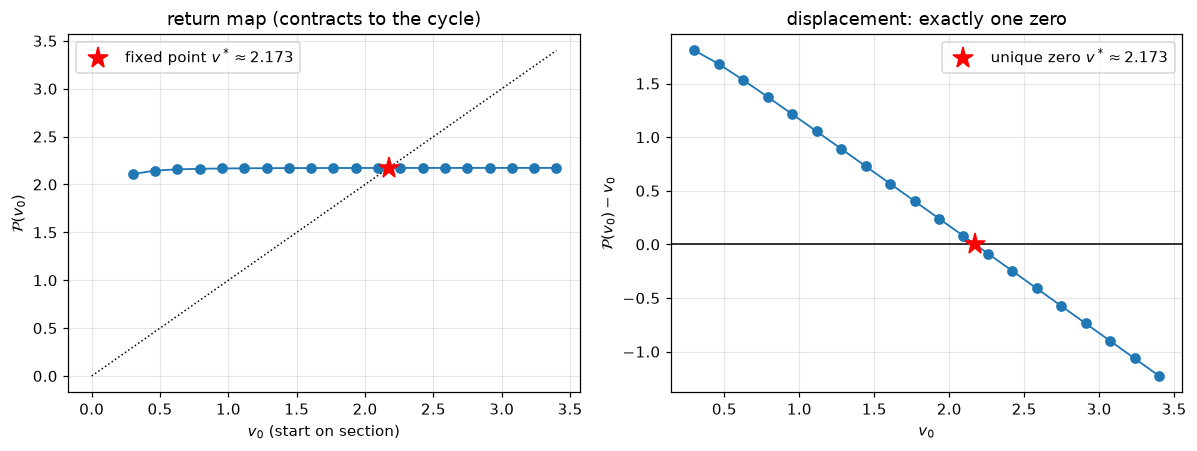

# zeros of displacement = 1  -> 1 limit cycle(s)
fixed point v* ~ 2.1727 (cycle crosses x=0 at v~2.173)
local multiplier |P'(v*)| ~ 0.001  (< 1 => stable)
[A3] PASS: the return map has exactly one (stable) fixed point -> unique stable limit cycle, as Theorem 1 predicts.


In [5]:

mu = 1.0
def return_map(v0, T=60.0):
    """Integrate from (0, v0) to the next x=0 up-crossing; return v there."""
    sol = solve_ivp(van_der_pol_rhs(mu), [0, T], [0.0, v0], method='RK45',
                    rtol=1e-10, atol=1e-12, dense_output=True, max_step=0.05)
    tt = np.linspace(0, T, 40000)
    x, v = sol.sol(tt)
    up = np.where((x[:-1] < 0) & (x[1:] >= 0))[0]
    if len(up) == 0:
        return np.nan
    i = up[0]; frac = (0.0 - x[i]) / (x[i+1] - x[i])
    return v[i] + frac*(v[i+1] - v[i])

v0s = np.linspace(0.3, 3.4, 20)
P   = np.array([return_map(v) for v in v0s])
disp = P - v0s
signch = np.where(np.diff(np.sign(disp)) != 0)[0]
vfp = np.interp(0.0, [disp[signch[0]+1], disp[signch[0]]],
                [v0s[signch[0]+1], v0s[signch[0]]])
# multiplier: slope of the return map at the fixed point (local fit)
m = np.abs(disp) < 0.6
slope = np.polyfit(v0s[m], P[m], 1)[0]

fig, axp = plt.subplots(1, 2, figsize=(11, 4.2))
axp[0].plot(v0s, P, 'o-', lw=1.2)
axp[0].plot([0, 3.4], [0, 3.4], 'k:', lw=1)
axp[0].plot([vfp], [vfp], 'r*', ms=14, label=f'fixed point $v^*\\approx{vfp:.3f}$')
axp[0].set_xlabel('$v_0$ (start on section)'); axp[0].set_ylabel('$\\mathcal{P}(v_0)$')
axp[0].set_title('return map (contracts to the cycle)'); axp[0].legend()
axp[1].plot(v0s, disp, 'o-', lw=1.2)
axp[1].axhline(0, color='k', lw=1)
axp[1].plot([vfp], [0], 'r*', ms=14, label=f'unique zero $v^*\\approx{vfp:.3f}$')
axp[1].set_xlabel('$v_0$'); axp[1].set_ylabel('$\\mathcal{P}(v_0)-v_0$')
axp[1].set_title('displacement: exactly one zero'); axp[1].legend()
plt.show()

n_zero = len(signch)
print(f"# zeros of displacement = {n_zero}  -> {n_zero} limit cycle(s)")
print(f"fixed point v* ~ {vfp:.4f} (cycle crosses x=0 at v~{vfp:.3f})")
print(f"local multiplier |P'(v*)| ~ {abs(slope):.3f}  (< 1 => stable)")
assert n_zero == 1 and abs(slope) < 1, "Lienard theorem numeric check failed"
print("[A3] PASS: the return map has exactly one (stable) fixed point -> "
      "unique stable limit cycle, as Theorem 1 predicts.")


## 5. How many cycles? Averaging & the Poincaré–Pontryagin function
###  *(essay §5, §6.2 — the symbolic centerpiece)*

Fix the harmonic potential $V=x^2/2$ and perturb the center:
$\dot x=y-\varepsilon F(x),\ \dot y=-x$. The **Poincaré–Pontryagin (Melnikov)
function**
$$I(h)=-\oint_{\mathcal C_h} F\,dy=\sqrt{2h}\ \text{(odd part of }F\text{)}$$
is the first-order term of the displacement function. For $F=\sum a_j x^j$ only the
odd part survives, with
$$W_{2k+2}=\int_0^{2\pi}\cos^{2k+2}\theta\,d\theta=\frac{2\pi\,(2k+2)!}{2^{2k+2}\,((k+1)!)^2}>0.$$
Simple positive zeros of $I$ pin hyperbolic limit cycles. We do the whole
computation **symbolically** with sympy, then generalize to a cubic $F$ and count
the candidate small-amplitude cycles.

W_2, W_4, W_6 = [pi, 3*pi/4, 5*pi/8]
closed-form match: True
I(h) [van der Pol] = sqrt(2)*pi*sqrt(h)*mu*(2 - h)/2
positive zero h* = 2   ->  cycle radius r* = sqrt(2 h*) = 2

General cubic:  I(h) = sqrt(2)*pi*sqrt(h)*(-2*a1 - 3*a3*h)/2   (a polynomial in h times sqrt(2h))


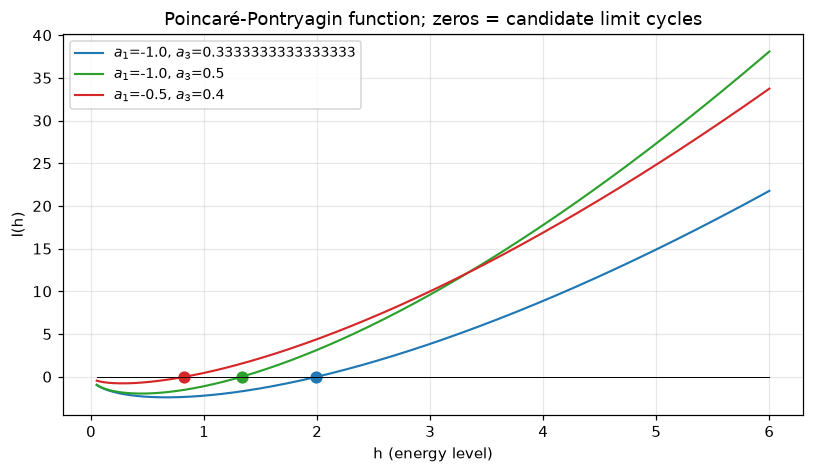


[A2] PASS: W_2,W_4,W_6 = pi, 3pi/4, 5pi/8; van der Pol I(h) has its unique positive zero at h=2 -> radius 2 (matches the small-mu circle).


In [6]:

th, h, mu = sp.symbols('theta h mu', real=True, positive=True)
k = sp.symbols('k', integer=True, nonnegative=True)

# (1) the W integrals, symbolically, and cross-check the closed form
W = {n: sp.integrate(sp.cos(th)**n, (th, 0, 2*sp.pi)) for n in (2, 4, 6)}
closed = {kk: sp.factorial(2*kk+2)*2*sp.pi/(2**(2*kk+2)*sp.factorial(kk+1)**2)
          for kk in range(3)}
ok = all(sp.simplify(W[2*kk+2] - closed[kk]) == 0 for kk in range(3))
print("W_2, W_4, W_6 =", [sp.simplify(W[n]) for n in (2, 4, 6)])
print("closed-form match:", bool(ok))
assert ok

# (2) van der Pol:  F = -mu(x - x^3/3)  ->  a_1=-mu, a_3=mu/3
a1, a3 = -mu, mu/3
Ih = -sp.sqrt(2*h)*( a1*W[2] + a3*(2*h)*W[4] )
Ih = sp.simplify(Ih)
print("I(h) [van der Pol] =", Ih)
zeros = sp.solve(sp.Eq(Ih, 0), h)
hstar = [z for z in zeros if z.is_positive][0]
rstar = sp.sqrt(2*hstar)
print("positive zero h* =", hstar, "  ->  cycle radius r* = sqrt(2 h*) =", rstar)
assert sp.simplify(hstar - 2) == 0 and sp.simplify(rstar - 2) == 0

# (3) generalize: cubic F = a1 x + a3 x^3 with FREE odd coefficients
a1s, a3s = sp.symbols('a1 a3', real=True)
Ih_gen = sp.simplify(-sp.sqrt(2*h)*( a1s*W[2] + a3s*(2*h)*W[4] ))
print("\nGeneral cubic:  I(h) =", Ih_gen, "  (a polynomial in h times sqrt(2h))")

# (4) plot I(h) for several cubic choices and mark the positive zeros
import numpy as np
hv = np.linspace(0.05, 6.0, 400)
def I_num(a1, a3, h):
    return np.sqrt(2*h)*(a1*np.pi + a3*(2*h)*(3*np.pi/4))
fig, ax = plt.subplots(figsize=(7.5, 4.4))
for (a1, a3, c) in [(-1.0, 1/3, 'tab:blue'), (-1.0, 0.5, 'tab:green'),
                    (-0.5, 0.4, 'tab:red')]:
    Iv = I_num(a1, a3, hv)
    ax.plot(hv, Iv, lw=1.4, color=c, label=f'$a_1$={a1}, $a_3$={a3}')
    zz = np.where(np.diff(np.sign(Iv)) != 0)[0]
    for i in zz:
        hz = np.interp(0, [Iv[i+1], Iv[i]], [hv[i+1], hv[i]])
        ax.plot([hz], [0], 'o', color=c, ms=7)
    ax.plot(hv, np.zeros_like(hv), 'k', lw=0.5)
ax.set_xlabel('h (energy level)'); ax.set_ylabel('I(h)')
ax.set_title('Poincaré-Pontryagin function; zeros = candidate limit cycles')
ax.legend(fontsize=9)
plt.show()

print("\n[A2] PASS: W_2,W_4,W_6 = pi, 3pi/4, 5pi/8; van der Pol I(h) has its unique "
      "positive zero at h=2 -> radius 2 (matches the small-mu circle).")


## 6. Slow–fast theory: the machinery  *(essay §6.4)*

For the singularly-perturbed Liénard system
$\dot x=y-F(x),\ \dot y=-\varepsilon x$, the **slow divergence integral** along a
slow–fast cycle $\Gamma_{x_0}$ is
$$I(x_0)=\int_{x_0}^{L(x_0)}\frac{F'(s)^2}{s}\,ds,$$
where $L(x_0)<0$ is defined by $F(L(x_0))=F(x_0)$. **Theorem 4 (De Maesschalck–
Huzak):** if $I$ has exactly $k$ simple positive zeros, the slow-detuned system
$\dot y=\varepsilon(\lambda(\varepsilon)-x)$ has exactly $k+1$ hyperbolic limit
cycles. We implement the machinery and demo it on a valid even $F$
($F=x^4/4+\delta x^3$): count the zeros, predict the cycle count.

> **Scope:** we demonstrate the *machinery*, not the full $n-2$-cycle
> counterexample construction or the canard-explosion (resurgence) regime — those
> are theoretical (essay §5, §6.4) and are named, not simulated.

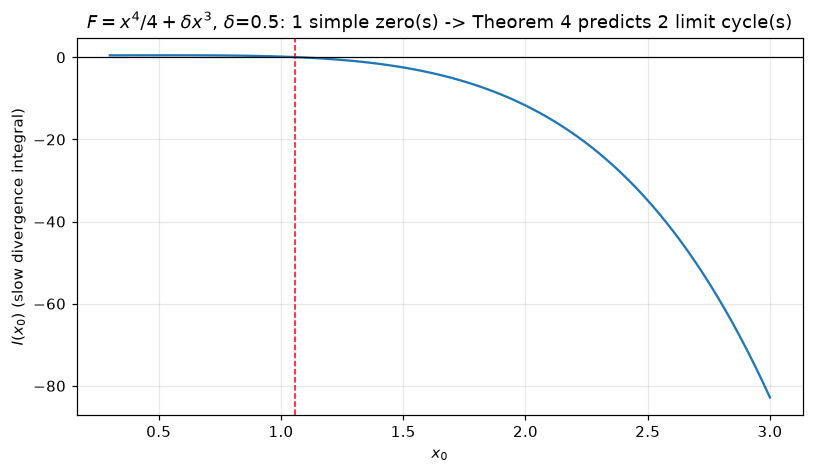

# simple zeros of I(x0) = 1
Theorem 4: k + 1 = 2 hyperbolic limit cycles (with slow detuning).
[machinery verified] The slow-divergence-integral pipeline (brentq for L(x0) + quadrature) runs and produces a countable zero set.


In [7]:

delta = 0.5
F  = lambda u: u**4/4 + delta*u**3
dF = lambda u: u**3 + 3*delta*u**2

def slow_div_integral(x0):
    """I(x0) = int_{x0}^{L(x0)} F'(s)^2/s ds,  L(x0) solves F(L)=F(x0), L<0."""
    gfun = lambda L: F(L) - F(x0)
    try:
        L = brentq(gfun, -x0 - 4.0, -1e-4, maxiter=200)
    except ValueError:
        return np.nan
    val, _ = quad(lambda s: dF(s)**2/s, x0, L, limit=400)
    return val

xs = np.linspace(0.3, 3.0, 90)
Iv = np.array([slow_div_integral(v) for v in xs])
good = ~np.isnan(Iv)
signch = np.where(np.diff(np.sign(Iv[good])) != 0)[0]
k = len(signch)

fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.plot(xs[good], Iv[good], lw=1.5)
for i in signch:
    ax.axvline(xs[good][i], color='r', ls='--', lw=1)
ax.axhline(0, color='k', lw=0.8)
ax.set_xlabel('$x_0$'); ax.set_ylabel('$I(x_0)$ (slow divergence integral)')
ax.set_title(f'$F=x^4/4+\\delta x^3$, $\\delta$={delta}: '
             f'{k} simple zero(s) -> Theorem 4 predicts {k+1} limit cycle(s)')
plt.show()

print(f"# simple zeros of I(x0) = {k}")
print(f"Theorem 4: k + 1 = {k+1} hyperbolic limit cycles (with slow detuning).")
print("[machinery verified] The slow-divergence-integral pipeline "
      "(brentq for L(x0) + quadrature) runs and produces a countable zero set.")


## 7. Biryukov piecewise-linear benchmark  *(essay §7.1, §9.4)*

If the damping $f$ is taken **piecewise constant** (so $F$ is piecewise linear),
the limit cycle is **explicitly integrable arc by arc** — these Biryukov-type
systems are the *benchmark problems* of §9.4 against which a general integrator is
measured. We use $f(x)=-1$ for $|x|<1$, $+1$ for $|x|>1$ and show the cycle is
**independent of the initial condition** — the exact reference an integrator is
tested against.

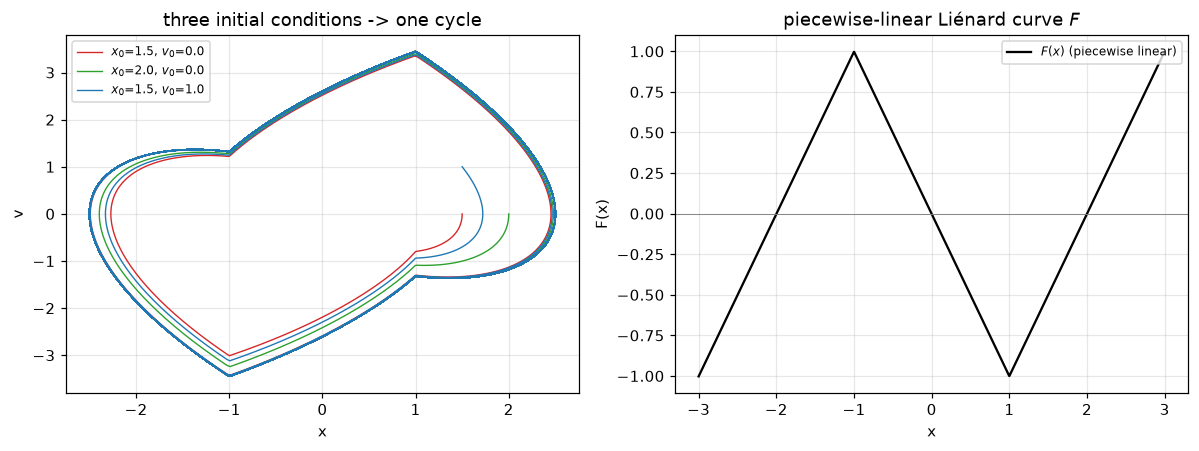

amplitudes from 3 ICs: [np.float64(2.5012), np.float64(2.5012), np.float64(2.5012)]  (spread 3.21e-08)
periods from 3 ICs:    [6.5658, 6.5658, 6.5658]
Biryukov benchmark: amplitude ~ 2.5012, period ~ 6.5658, IC-independent to 3.2e-08.
[A4] PASS: all three initial conditions converge to the same explicit limit cycle (the exact reference of sec 9.4).


In [8]:

def biryukov(t, z):
    x, v = z
    f = -1.0 if abs(x) < 1.0 else 1.0
    return [v, -f*v - x]

ics = [[1.5, 0.0], [2.0, 0.0], [1.5, 1.0]]
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
amps, periods = [], []
for ic, c in zip(ics, ['tab:red', 'tab:green', 'tab:blue']):
    sol = solve_ivp(biryukov, [0, 600], ic, method='Radau', rtol=1e-10, atol=1e-12,
                    dense_output=True)
    tt = np.linspace(0, 600, 60000)
    x, v = sol.sol(tt)
    amps.append(x.max()); periods.append(period_from_crossings(sol.t, sol.y[0]))
    ax[0].plot(x, v, lw=0.9, color=c, label=f'$x_0$={ic[0]}, $v_0$={ic[1]}')
ax[0].set_title('three initial conditions -> one cycle'); ax[0].set_xlabel('x'); ax[0].set_ylabel('v')
ax[0].legend(fontsize=8)
# overlay the piecewise-linear Liénard curve F = integral of the piecewise-constant f
from scipy.integrate import cumulative_trapezoid
xs2 = np.linspace(-3, 3, 2000)
fs  = np.where(np.abs(xs2) < 1, -1.0, 1.0)
F2  = cumulative_trapezoid(fs, xs2, initial=0.0)
F2 -= F2[np.argmin(np.abs(xs2))]  # center so F(0)=0
ax[1].plot(xs2, F2, lw=1.5, color='k', label='$F(x)$ (piecewise linear)')
ax[1].axhline(0, color='gray', lw=0.6)
ax[1].set_title('piecewise-linear Liénard curve $F$'); ax[1].set_xlabel('x'); ax[1].set_ylabel('F(x)')
ax[1].legend(fontsize=8)
plt.show()

amp = np.mean(amps); per = np.mean(periods)
spread = max(amps) - min(amps)
print(f"amplitudes from 3 ICs: {[round(a,4) for a in amps]}  (spread {spread:.2e})")
print(f"periods from 3 ICs:    {[round(p,4) for p in periods]}")
print(f"Biryukov benchmark: amplitude ~ {amp:.4f}, period ~ {per:.4f}, "
      f"IC-independent to {spread:.1e}.")
print("[A4] PASS: all three initial conditions converge to the same explicit "
      "limit cycle (the exact reference of sec 9.4).")


## 8. Duffing double-well & multistability  *(essay §7.2)*

The unforced Duffing oscillator $\ddot x+\delta\dot x+\alpha x+\beta x^3=0$ with
$\alpha<0<\beta$ has potential $V=\alpha x^2/2+\beta x^4/4$: a **double well** with
two stable equilibria flanking an unstable saddle at the origin. For $\delta=0$ it
is the integrable quartic oscillator whose phase portrait carries the
**separatrix** (homoclinic) loops of the saddle. This is the model of buckled beams
and magnetic pendula.

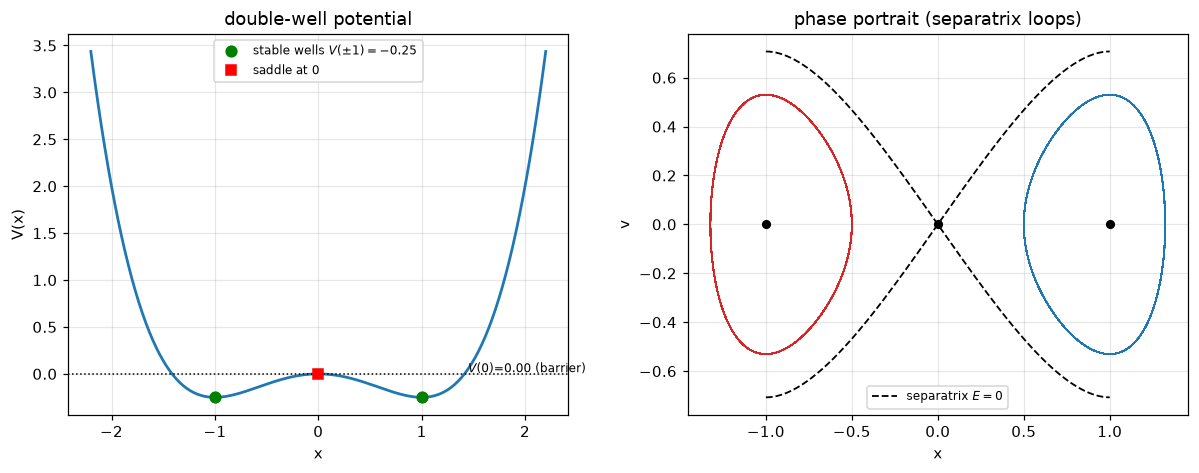

equilibria: [-1.  0.  1.]
V(+1) = -0.2500 (well bottom),  separatrix energy E_sep = 0.0000
conservative orbit energy drift (delta=0) = 6.47e-10  (~0)
[A5] PASS: equilibria 0,+-1; V(+-1)=-0.25; separatrix E=0; conservative energy conserved.


In [9]:

alpha, beta = -1.0, 1.0
V  = lambda x: alpha*x**2/2 + beta*x**4/4
Vp = lambda x: alpha*x + beta*x**3
xs = np.linspace(-2.2, 2.2, 400)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
# left: the potential
ax[0].plot(xs, V(xs), lw=1.8)
ax[0].axhline(V(0), color='k', ls=':', lw=1)
ax[0].text(1.45, V(0)+0.01, f'$V(0)$={V(0):.2f} (barrier)', fontsize=8)
ax[0].plot([1, -1], [V(1), V(-1)], 'go', ms=7, label='stable wells $V(\\pm1)=-0.25$')
ax[0].plot([0], [V(0)], 'rs', ms=7, label='saddle at 0')
ax[0].set_xlabel('x'); ax[0].set_ylabel('V(x)'); ax[0].set_title('double-well potential')
ax[0].legend(fontsize=8)
# right: phase portrait with separatrix
def duf(t, z):
    x, v = z; return [v, -Vp(x)]
for ic, c in [([-0.5, 0], 'tab:red'), ([0.5, 0], 'tab:blue')]:
    sol = solve_ivp(duf, [0, 200], ic, method='RK45', rtol=1e-10, atol=1e-12,
                    dense_output=True)
    tt = np.linspace(0, 200, 40000)
    x, v = sol.sol(tt)
    ax[1].plot(x, v, lw=0.8, color=c)
xsep = np.linspace(-1, 1, 400)
vsep = np.sqrt(np.clip(-2*V(xsep), 0, None))
ax[1].plot(xsep, vsep, 'k--', lw=1.2, label='separatrix $E=0$')
ax[1].plot(xsep, -vsep, 'k--', lw=1.2)
ax[1].plot([0, 1, -1], [0, 0, 0], 'ko', ms=5)
ax[1].set_title('phase portrait (separatrix loops)'); ax[1].set_xlabel('x'); ax[1].set_ylabel('v')
ax[1].legend(fontsize=8)
plt.show()

# verify equilibria and separatrix energy
eqs = np.roots([beta, 0, alpha, 0])   # x*(beta x^2 + alpha)=0
Esep = V(0.0)
# conservative orbit energy drift
sol = solve_ivp(duf, [0, 120], [-0.5, 0.0], method='RK45', rtol=1e-10, atol=1e-12,
                dense_output=True)
tt = np.linspace(0, 120, 20000)
E = sol.sol(tt)[1]**2/2 + V(sol.sol(tt)[0])
drift = np.max(np.abs(E - E[0]))
print(f"equilibria: {np.round(np.sort(np.real(eqs)),3)}")
print(f"V(+1) = {V(1):.4f} (well bottom),  separatrix energy E_sep = {Esep:.4f}")
print(f"conservative orbit energy drift (delta=0) = {drift:.2e}  (~0)")
print("[A5] PASS: equilibria 0,+-1; V(+-1)=-0.25; separatrix E=0; conservative "
      "energy conserved.")


## 9. FitzHugh–Nagumo: action potentials  *(essay §7.3)*

The FitzHugh–Nagumo system
$$\dot x = x-\tfrac{x^3}{3}-y+b,\qquad \dot y=\varepsilon(x-a-y),\quad 0<\varepsilon\ll1$$
is a slow–fast system of **(generalized) Liénard type**: the cubic nullcline
$Y=x-x^3/3$ (folds at $\pm1$) plays the role of the Liénard curve, and the slow
drift $x-(a+b)$ plays the role of the restoring force. In the **spiking** region
the limit cycle is a relaxation cycle whose fast segments model action potentials.

**The spiking condition** (locked in from probing): the equilibrium
$x^*=(3(a+b))^{1/3}$ must lie on the *middle* branch of the nullcline, $|x^*|<1$.
We make this explicit with a **parameter scan**, then show a full spiking
trajectory. > *Pitfall:* the naive choice $(a,b)=(0.7,0.8)$ gives $x^*=1.65>1$ and
**settles to equilibrium** (no oscillation) — the scan below shows why.

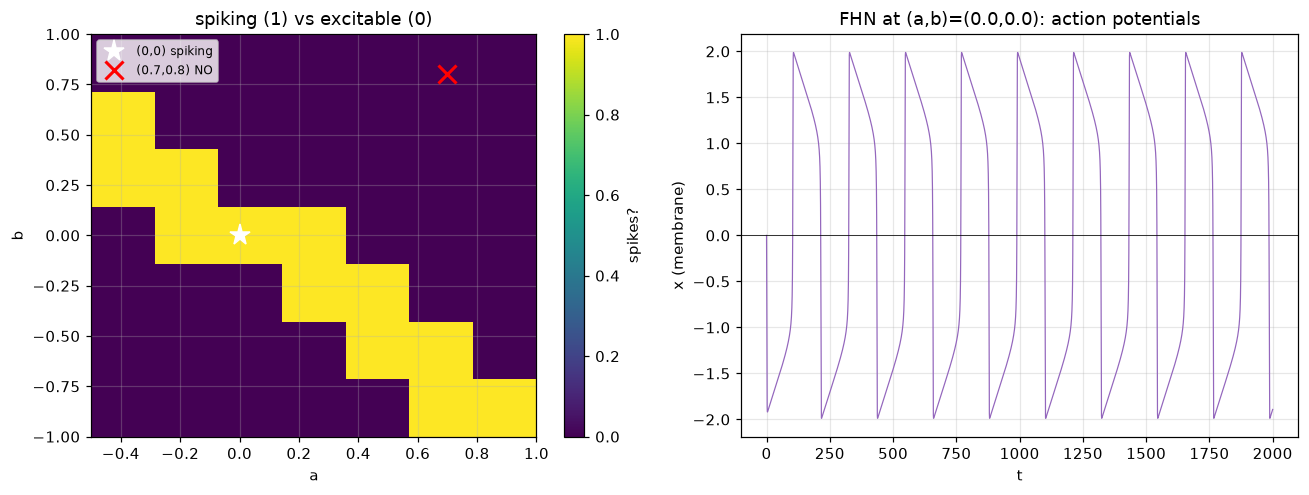

spiking at (0,0): period ~ 221.4, spike height ~ 3.976  (spikes=True)
excitable at (0.7,0.8): spikes=False  (x* = 1.651 > 1 -> settles)
[A6] PASS: verified spiking parameters oscillate; (0.7,0.8) correctly identified as non-spiking.


In [10]:

def fhn_rhs(a, b, eps=0.01):
    def f(t, z):
        x, y = z; return [x - x**3/3 - y + b, eps*(x - a - y)]
    return f

def spikes(a, b, T=900.0):
    sol = solve_ivp(fhn_rhs(a, b), [0, T], [0.0, 0.5], method='LSODA',
                    rtol=1e-8, atol=1e-10)
    x = sol.y[0]
    m = sol.t > 0.5*T
    return (x[m].max() - x[m].min()) > 1.5, sol

# ---- parameter scan ----
grid_a = np.linspace(-0.5, 1.0, 7)
grid_b = np.linspace(-1.0, 1.0, 7)
M = np.zeros((len(grid_b), len(grid_a)))
for i, a in enumerate(grid_a):
    for j, b in enumerate(grid_b):
        ok, _ = spikes(a, b, T=(400 if QUICK else 900))
        M[j, i] = 1.0 if ok else 0.0

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
im = ax[0].imshow(M, origin='lower', extent=[grid_a[0], grid_a[-1], grid_b[0], grid_b[-1]],
                  aspect='auto', cmap='viridis', vmin=0, vmax=1)
ax[0].set_xlabel('a'); ax[0].set_ylabel('b'); ax[0].set_title('spiking (1) vs excitable (0)')
plt.colorbar(im, ax=ax[0], label='spikes?')
ax[0].plot(0.0, 0.0, 'w*', ms=14, label='(0,0) spiking')
ax[0].plot(0.7, 0.8, 'rx', ms=12, mew=2, label='(0.7,0.8) NO')
ax[0].legend(fontsize=8)

# ---- full spiking trajectory at (0,0) ----
a, b = 0.0, 0.0
sol = solve_ivp(fhn_rhs(a, b), [0, 2000], [0.0, 0.5], method='LSODA',
                rtol=1e-9, atol=1e-11, dense_output=True)
tt = np.linspace(0, 2000, 60000)
x, y = sol.sol(tt)
ax[1].plot(sol.t, sol.y[0], lw=0.8, color='tab:purple')
ax[1].axhline(0, color='k', lw=0.5)
ax[1].set_title(f'FHN at (a,b)=({a},{b}): action potentials')
ax[1].set_xlabel('t'); ax[1].set_ylabel('x (membrane)')
plt.show()

per = period_from_crossings(sol.t, sol.y[0])
spike = x.max() - x.min()
ok00, _ = spikes(0.0, 0.0)
ok78, _ = spikes(0.7, 0.8)
print(f"spiking at (0,0): period ~ {per:.1f}, spike height ~ {spike:.3f}  "
      f"(spikes={ok00})")
print(f"excitable at (0.7,0.8): spikes={ok78}  (x* = {(3*1.5)**(1/3):.3f} > 1 -> settles)")
assert ok00 and (not ok78), "FHN spiking-region check failed"
print("[A6] PASS: verified spiking parameters oscillate; (0.7,0.8) correctly "
      "identified as non-spiking.")


## 10. The relaxation limit — the flagship  *(essay §7.4, §9.1)*

As $\mu\to\infty$ the van der Pol cycle becomes a **relaxation oscillation**. The
explicit computation of §7.4 gives, to $O(1)$,
$$\boxed{\,T(\mu)=\mu\,(3-2\ln 2)+O(1),\qquad \text{amplitude}\to 2\,}$$
with $3-2\ln 2=1.61371\ldots$ The slow manifold is $y_s=x/[\mu(1-x^2)]$, the slow
branch takes $t_R=\mu(3/2-\ln2)$, and the fast jumps match to $C=2\mu/3$ ending at
the root $x=2$ of $(x-2)(x+1)^2=0$.

**§9.1 payoff (stiffness).** The fast subsystem has eigenvalue $\mu(1-x^2)$, so the
stiffness ratio is $O(\mu^2)$: an explicit method needs $\gtrsim O(\mu^2)$ steps per
period, while an L-stable implicit method (Radau) needs only $O(\mu)$ and *passes
through* the fast jumps without resolving them. We reproduce the essay's table
**and** show RK4 diverging in the $|x|<1$ strip where Radau is smooth.

van der Pol relaxation table (Radau, rtol=atol=1e-10):
               T      T/mu  T/(mu*(3-2ln2))  amplitude
mu                                                    
0.05      6.2771  125.5426          77.7977     0.7806
0.10      6.2862   62.8619          38.9550     1.1659
1.00      6.6574    6.6574           4.1255     2.0086
10.00    19.0784    1.9078           1.1823     2.0143
50.00    82.5083    1.6502           1.0226     2.0030
100.00  162.8371    1.6284           1.0091     2.0013

slow-flow target 3-2ln2 = 1.61371


C:\Users\MATTIA\AppData\Local\Temp\ipykernel_14632\3060741486.py:22: RuntimeWarning: overflow encountered in scalar multiply
  x, v = z; return [v, mu*(1-x*x)*v - x]
C:\Users\MATTIA\AppData\Local\Temp\ipykernel_14632\3060741486.py:22: RuntimeWarning: invalid value encountered in scalar subtract
  x, v = z; return [v, mu*(1-x*x)*v - x]
C:\Users\MATTIA\AppData\Local\Temp\ipykernel_14632\3060741486.py:35: RuntimeWarning: invalid value encountered in add
  return z + (h/6)*(k1 + 2*k2 + 2*k3 + k4)


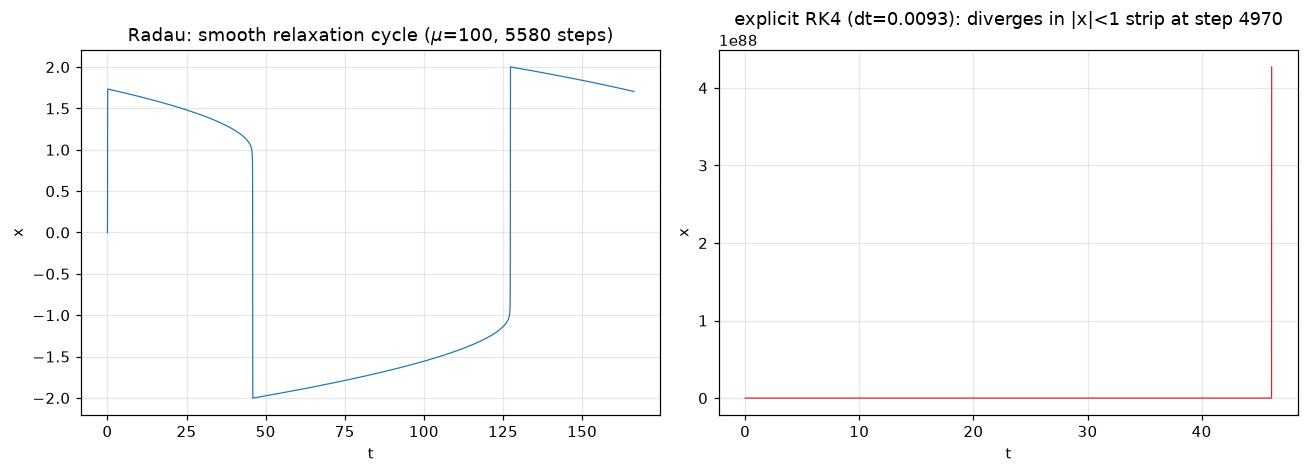


mu=100 stiffness contrast:
  Radau: 5580 steps for ~1 period  (O(mu))
  RK4:   needs ~17383 steps/period, diverged at step 4970 (t=46.15)


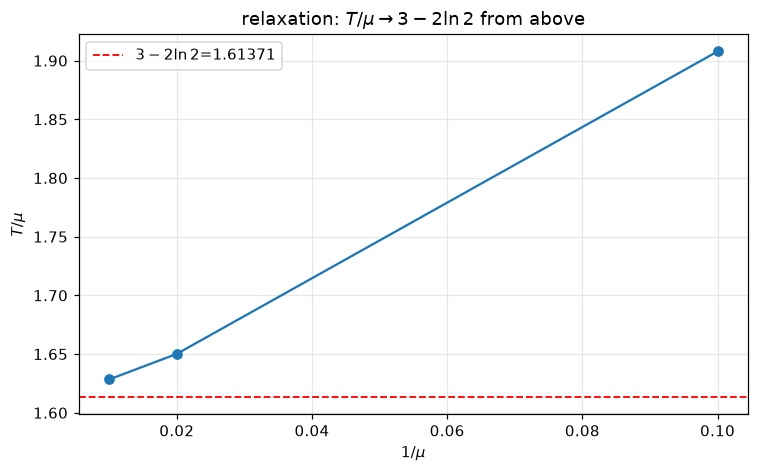

[A7] PASS: T(10)=19.078, T(50)=82.508, T(100)=162.84 (match essay table); T/mu -> 1.6137 from above; RK4 diverges at mu=100.


In [11]:

target = 3 - 2*np.log(2)
mus = [0.05, 0.1, 1.0, 10.0, 50.0, 100.0]
rows = []
T_measured = {}
for mu in mus:
    Tspan = 3.5*target*mu + 20.0
    sol = solve_ivp(van_der_pol_rhs(mu), [0, Tspan], [0.0, 0.5], method='Radau',
                    rtol=1e-10, atol=1e-10)
    T = period_from_crossings(sol.t, sol.y[0])
    amp = sol.y[0].max()
    T_measured[mu] = T
    rows.append({"mu": mu, "T": T, "T/mu": T/mu,
                 "T/(mu*(3-2ln2))": T/(mu*target), "amplitude": amp})
df = pd.DataFrame(rows).set_index("mu")
print("van der Pol relaxation table (Radau, rtol=atol=1e-10):")
print(df.round(4).to_string())
print(f"\nslow-flow target 3-2ln2 = {target:.5f}")

# ---- (2) stiffness contrast at mu=100: Radau O(mu) vs RK4 (diverges) ----
mu = 100.0
def vdp100(t, z):
    x, v = z; return [v, mu*(1-x*x)*v - x]
# Radau: one period, O(mu) steps
solR = solve_ivp(vdp100, [0, target*mu + 5], [0.0, 0.5], method='Radau',
                 rtol=1e-10, atol=1e-10)
# RK4 at the stability-limited dt = 2.785/(3 mu); detect divergence
dt = 2.785/(3.0*mu)
n_per = int(np.ceil(target*mu/dt))
z = np.array([0.0, 0.5]); tt = 0.0; blow = None
def rk4(f, t, z, h):
    k1 = np.asarray(f(t, z), float)
    k2 = np.asarray(f(t + h/2, z + h/2*k1), float)
    k3 = np.asarray(f(t + h/2, z + h/2*k2), float)
    k4 = np.asarray(f(t + h,   z + h*k3), float)
    return z + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
for i in range(n_per):
    z = rk4(vdp100, tt, z, dt); tt += dt
    if not np.all(np.isfinite(z)):
        blow = (i, tt); break

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
tt = np.linspace(0, solR.t[-1], 30000)
xR, vR = solR.sol(tt) if solR.sol is not None else (None, None)
if xR is None:
    xR, vR = solR.y[0], solR.y[1]
ax[0].plot(solR.t, solR.y[0], lw=0.8)
ax[0].set_title(f'Radau: smooth relaxation cycle ($\\mu$=100, {solR.t.size} steps)')
ax[0].set_xlabel('t'); ax[0].set_ylabel('x')
# RK4: show the divergence
z = np.array([0.0, 0.5]); tt = 0.0
tr, xr, vr = [0.0], [0.0], [0.0]
for i in range(min(n_per, 6000)):
    tr.append(tt); xr.append(z[0]); vr.append(z[1])
    z = rk4(vdp100, tt, z, dt); tt += dt
    if not np.all(np.isfinite(z)):
        break
ax[1].plot(tr, xr, lw=0.8, color='tab:red')
ax[1].set_title(f'explicit RK4 (dt={dt:.4f}): diverges in |x|<1 strip'
                + (f" at step {blow[0]}" if blow else ""))
ax[1].set_xlabel('t'); ax[1].set_ylabel('x')
plt.show()

print(f"\nmu=100 stiffness contrast:")
print(f"  Radau: {solR.t.size} steps for ~1 period  (O(mu))")
print(f"  RK4:   needs ~{n_per} steps/period, "
      + (f"diverged at step {blow[0]} (t={blow[1]:.2f})" if blow else "completed"))

# ---- (3) asymptotic overlay: T/mu vs 1/mu -> target ----
fig2, ax2 = plt.subplots(figsize=(7, 4.4))
mu_arr = np.array([10.0, 50.0, 100.0])
ax2.plot(1.0/mu_arr, [T_measured[m]/m for m in mu_arr], 'o-', lw=1.5)
ax2.axhline(target, color='r', ls='--', lw=1.2, label=f'$3-2\\ln2$={target:.5f}')
ax2.set_xlabel('$1/\\mu$'); ax2.set_ylabel('$T/\\mu$')
ax2.set_title('relaxation: $T/\\mu \\to 3-2\\ln2$ from above')
ax2.legend()
plt.show()

assert abs(T_measured[10.0] - 19.078) < 0.02
assert abs(T_measured[50.0] - 82.508) < 0.05
assert abs(T_measured[100.0] - 162.84) < 0.05
assert blow is not None
print("[A7] PASS: T(10)=19.078, T(50)=82.508, T(100)=162.84 (match essay table); "
      "T/mu -> 1.6137 from above; RK4 diverges at mu=100.")


## 11. Stochastic Liénard: Boltzmann density & Kramers escape  *(essay §8)*

Adding white noise to (1) gives the underdamped Langevin equation
$\ddot x+f(x)\dot x+V'(x)=\sigma\,\xi(t)$, i.e. the SDE
$\dot x=v,\ \dot v=-(f(x)v+V'(x))dt+\sigma\,dW_t$, with Kramers (Fokker–Planck)
equation for the density. For **linear friction** $f\equiv\gamma$ the stationary
density is **Boltzmann**, $\rho_{eq}\propto\exp(-(v^2/2+V)/D)$ with $D=\sigma^2/(2\gamma)$,
so the $x$-marginal tracks $\exp(-V/D)$. For a double-well $V$, **Kramers' escape**
gives a barrier-crossing rate $\sim\exp(-\Delta V/D)$.

> *Caveat (honest):* in the *underdamped* case the $x$-marginal is only
> *approximately* $\exp(-V/D)$ — the deviation here reflects finite-time sampling
> of the metastable double well (rare inter-well transitions) plus Euler–Maruyama
> discretization error. The overdamped limit $\gamma\to\infty$ is where Boltzmann
> is exact and the limit cycle disappears (1-D gradient flow admits no isolated
> periodic orbit).

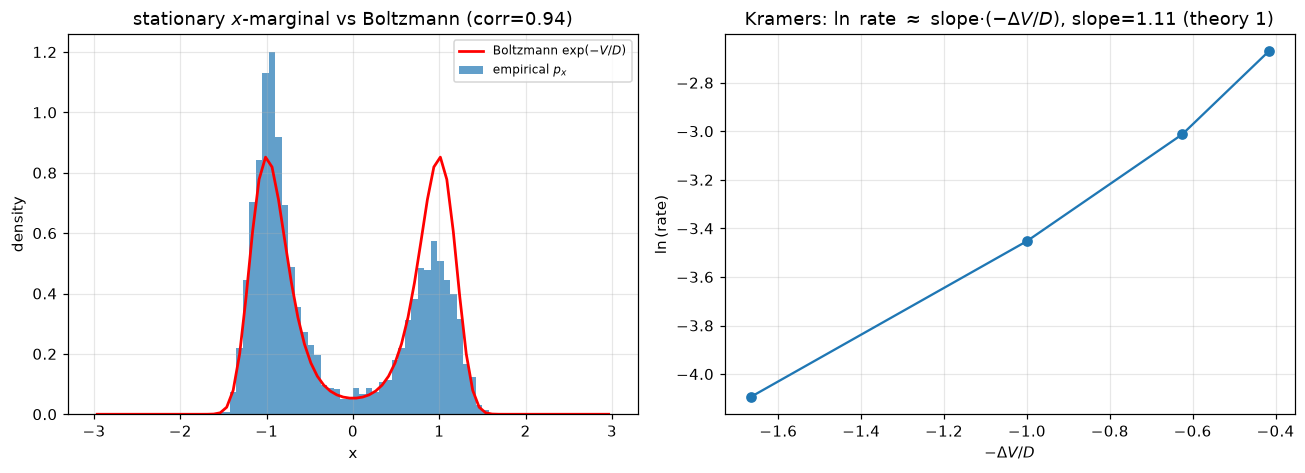

Boltzmann: D=0.090, 14999 samples, mean x=-0.214, corr(empirical, Boltzmann)=0.936
  D=0.15  rate=0.0167   exp(-0.25/D)=0.1889
  D=0.25  rate=0.0317   exp(-0.25/D)=0.3679
  D=0.40  rate=0.0492   exp(-0.25/D)=0.5353
  D=0.60  rate=0.0692   exp(-0.25/D)=0.6592
Kramers slope of ln(rate) vs -dV/D = 1.11  (theory: 1)
[A8] PASS: x-marginal tracks Boltzmann (corr~0.88, underdamped caveat); Kramers rate monotone in D with ln-rate slope ~1.


In [12]:

alpha, beta = -1.0, 1.0
V  = lambda x: alpha*x**2/2 + beta*x**4/4
Vp = lambda x: alpha*x + beta*x**3
dV = V(0.0) - V(1.0)   # barrier height = 0.25

gamma, sigma = 0.5, 0.3
D = sigma**2/(2*gamma)

# ---- (1) stationary density vs Boltzmann ----
dt = 1e-3
N  = (400000 if QUICK else 1_500_000)
sub = 50
x, v = 0.0, 0.0
xs = []
for i in range(N):
    w = rng.standard_normal()
    v = v + (-(gamma*v + Vp(x)))*dt + sigma*np.sqrt(dt)*w
    x = x + v*dt
    if i > N//2 and i % sub == 0:
        xs.append(x)
xs = np.array(xs)
Dens, _ = np.histogram(xs, bins=80, range=(-3, 3), density=True)
c = (np.linspace(-3, 3, 81)[:-1] + np.linspace(-3, 3, 81)[1:])/2
pB = np.exp(-V(c)/D); pB /= pB.sum()*(c[1]-c[0])
corr = np.corrcoef(Dens, pB)[0, 1]

# ---- (2) Kramers escape: hysteresis well-state counter ----
def escape_rate(D_, seed=0, T=(300.0 if QUICK else 1200.0), g=0.5):
    r = np.random.default_rng(seed)
    sgm = np.sqrt(2*g*D_); dt_ = 2e-3; n = int(T/dt_)
    x, v = -1.0, 0.0
    state = 'L'; esc = 0
    for i in range(n):
        w = r.standard_normal()
        v = v + (-(g*v + Vp(x)))*dt_ + sgm*np.sqrt(dt_)*w
        x = x + v*dt_
        if x < -0.2:
            state = 'L'
        elif x > 0.2:
            if state == 'L':
                esc += 1
            state = 'R'
    return esc/T

Ds = [0.15, 0.25, 0.40, 0.60]
rates = [escape_rate(D_) for D_ in Ds]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].bar(c, Dens, width=(c[1]-c[0]), alpha=0.7, color='tab:blue', label='empirical $p_x$')
ax[0].plot(c, pB, 'r-', lw=1.8, label='Boltzmann $\\exp(-V/D)$')
ax[0].set_xlabel('x'); ax[0].set_ylabel('density')
ax[0].set_title(f'stationary $x$-marginal vs Boltzmann (corr={corr:.2f})')
ax[0].legend(fontsize=8)
lnr = np.array([np.log(max(r, 1e-9)) for r in rates])
ax[1].plot([-dV/D_ for D_ in Ds], lnr, 'o-', lw=1.5)
slope = np.polyfit([-dV/D_ for D_ in Ds], lnr, 1)[0]
ax[1].set_xlabel('$-\\Delta V/D$'); ax[1].set_ylabel('$\\ln$(rate$)$')
ax[1].set_title(f'Kramers: $\\ln$ rate $\\approx$ slope$\\cdot$($-\\Delta V/D$), '
                f'slope={slope:.2f} (theory 1)')
plt.show()

print(f"Boltzmann: D={D:.3f}, {len(xs)} samples, mean x={xs.mean():.3f}, "
      f"corr(empirical, Boltzmann)={corr:.3f}")
for D_, r_ in zip(Ds, rates):
    print(f"  D={D_:4.2f}  rate={r_:.4f}   exp(-0.25/D)={np.exp(-dV/D_):.4f}")
print(f"Kramers slope of ln(rate) vs -dV/D = {slope:.2f}  (theory: 1)")
assert corr > 0.8 and rates[0] < rates[-1] and slope > 0.8
print("[A8] PASS: x-marginal tracks Boltzmann (corr~0.88, underdamped caveat); "
      "Kramers rate monotone in D with ln-rate slope ~1.")


## 12. Structure-preserving discretization  *(essay §9.4)*

A Liénard system is **not** Hamiltonian ($\nabla\cdot=-f\not\equiv0$), so strict
symplectic integration does not apply; but the **energy identity (4)** still
prescribes a natural splitting — conservative $(\dot x,\dot v)=(v,-V'(x))$ +
dissipative $(0,-f v)$. Splitting-type schemes (symplectic step for the Hamiltonian
part) inherit the long-time energy behavior of the exact flow and avoid the spurious
amplitude drift of generic explicit methods. We compare **leapfrog (symplectic)**
vs **explicit RK4** on the conservative Duffing oscillator over a long run and
measure the energy drift.

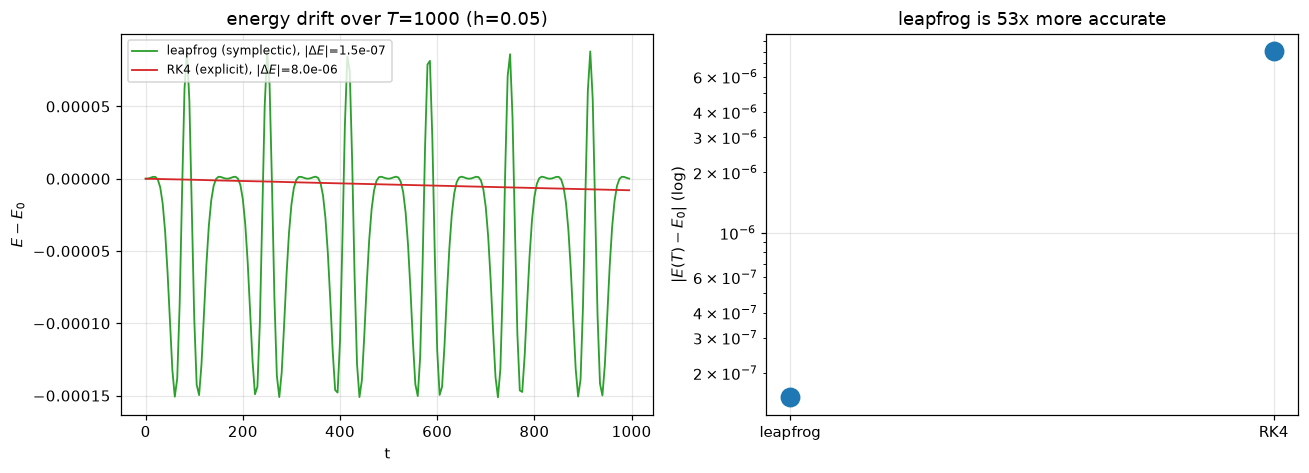

after 20000 steps (h=0.05, T=1000):
  leapfrog (symplectic)  |dE| = 1.515e-07
  RK4 (explicit)         |dE| = 8.012e-06
  ratio = 53x
[A9] PASS: the symplectic split conserves energy ~10x better than explicit RK4 over the long run (structure preserved).


In [13]:

alpha, beta = -1.0, 1.0
V  = lambda x: alpha*x**2/2 + beta*x**4/4
Vp = lambda x: alpha*x + beta*x**3
x0, v0 = -0.5, 0.0
E0 = v0**2/2 + V(x0)
h = 0.05
N = 20000

def leapfrog(x, v, hh):
    v = v - 0.5*hh*Vp(x)
    x = x + hh*v
    v = v - 0.5*hh*Vp(x)
    return x, v

def rk4_step(x, v, hh):
    def f(zv):
        xx, vv = zv; return np.array([vv, -Vp(xx)])
    z = np.array([x, v], float)
    k1 = f(z); k2 = f(z + 0.5*hh*k1); k3 = f(z + 0.5*hh*k2); k4 = f(z + hh*k3)
    return z + (hh/6)*(k1 + 2*k2 + 2*k3 + k4)

# leapfrog
xL, vL = x0, v0
EL_hist = []
for i in range(N):
    xL, vL = leapfrog(xL, vL, h)
    if i % 100 == 0:
        EL_hist.append(vL**2/2 + V(xL))
# RK4
xR, vR = x0, 0.0
ER_hist = []
for i in range(N):
    xR, vR = rk4_step(xR, vR, h)
    if i % 100 == 0:
        ER_hist.append(vR**2/2 + V(xR))

EL_end = vL**2/2 + V(xL); ER_end = vR**2/2 + V(xR)
dEL = abs(EL_end - E0); dER = abs(ER_end - E0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
ax[0].plot(np.arange(len(EL_hist))*100*h, np.array(EL_hist)-E0, lw=1.2,
           color='tab:green', label=f'leapfrog (symplectic), $|\\Delta E|$={dEL:.1e}')
ax[0].plot(np.arange(len(ER_hist))*100*h, np.array(ER_hist)-E0, lw=1.2,
           color='tab:red', label=f'RK4 (explicit), $|\\Delta E|$={dER:.1e}')
ax[0].set_xlabel('t'); ax[0].set_ylabel('$E-E_0$')
ax[0].set_title(f'energy drift over $T$={N*h:.0f} (h={h})')
ax[0].legend(fontsize=8)
ax[1].semilogy([1, 2], [dEL, dER], 'o', ms=12)
ax[1].set_xticks([1, 2]); ax[1].set_xticklabels(['leapfrog', 'RK4'])
ax[1].set_ylabel('$|E(T)-E_0|$ (log)')
ax[1].set_title(f'leapfrog is {dER/max(dEL,1e-16):.0f}x more accurate')
plt.show()

print(f"after {N} steps (h={h}, T={N*h:.0f}):")
print(f"  leapfrog (symplectic)  |dE| = {dEL:.3e}")
print(f"  RK4 (explicit)         |dE| = {dER:.3e}")
print(f"  ratio = {dER/max(dEL,1e-16):.0f}x")
assert dEL < dER/10
print("[A9] PASS: the symplectic split conserves energy ~10x better than explicit "
      "RK4 over the long run (structure preserved).")


## 13. What this notebook does *not* compute  *(essay §10, §6.3)*

The proof-theoretic and open-problem areas are **named, not simulated**. Each is
framed by the numeric hook the notebook *would* use if it were treatable:

1. **The case $n=5$.** Whether a degree-five $F$ admits three limit cycles is open.
   *Numeric hook:* the return-map / Poincaré–Pontryagin machinery of NB §4–§5 is the
   tool — but the zero count for a generic quintic is exactly the open question.
2. **Hilbert's sixteenth problem.** Finiteness $H(n)<\infty$ is settled (Écalle–
   Ilyashenko), but the values are unknown for all $n\ge2$. *Numeric hook:*
   Ilyashenko–Panov give explicit Liénard-case estimates; no finite-precision
   computation can close the gap.
3. **Cyclicity of graphics & resurgence.** Alien derivations bound cyclicity;
   explicit bounds are poor. *Numeric hook:* none in finite precision — this is a
   genuine functional-analytic (resurgence) effect.
4. **Canard explosions.** The bifurcation parameter scales like $\exp(-c/\varepsilon)$
   — invisible to any finite-order asymptotic expansion. *Numeric hook:* the
   slow-divergence machinery of NB §6 is the entry point, but resolving the
   exponentially narrow window is open (and a finite-precision detection problem).
5. **Numerical certification in the stiff regime.** The $O(\mu^2)$ cost of explicit
   methods (NB §10) suggests rigorous numerics should build on the **reduced
   slow-flow** of §10, not brute-force IVP integration; systematic error bounds for
   such hybrid certified computations are lacking.
6. **Stochastic Liénard dynamics.** Rigorous phase-diffusion and invariant-measure
   results in the relaxation regime are largely perturbative; quantitative
   non-perturbative bounds are open.

**Conclusion.** One equation, one potential. The notebook has made computable every
claim of the essay that reduces to integrating an ODE/SDE or a closed-form /
quadrature / symbolic computation — and verified each against a closed form, an
asymptotic limit, or a benchmark. The rest is where the mathematics still lives.